# Hybrid Crowd Counting — Step-by-step visualization

This notebook runs the hybrid pipeline on **one** image and visualizes the intermediates:
- averaged background
- CLAHE result
- absolute difference (image - background)
- binary foreground mask (before/after morphology)
- edge map (Canny)
- edges masked by foreground (edges ∧ mask)
- morphological edge refinements, filled contours and candidate mask
- head kernel (circular template)
- final blob detections (centroids & bounding boxes)

You can change the parameters in the `params` dict and re-run the visualization cell to tune behavior.


In [1]:
# Cell: Imports and helper display utilities

import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

# Import functions from your module
from crowd_counting import (
    ensure_gray,
    build_background_from_empty_images,
    centroids_from_binary_mask,
)

# Convenience: display a grid of images with titles
def show_images_grid(imgs_with_titles, cols=3, figsize=(14, 8), cmap='gray'):
    """
    imgs_with_titles: list of (img, title)
    img: HxW or HxWx3 (uint8 or float)
    """
    n = len(imgs_with_titles)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(imgs_with_titles, 1):
        ax = plt.subplot(rows, cols, i)
        if img is None:
            ax.text(0.5, 0.5, 'None', ha='center', va='center')
        else:
            if img.ndim == 2:
                ax.imshow(img, cmap=cmap, vmin=0, vmax=255)
            else:
                # assume BGR or RGB? we'll try to detect: if last dim==3 and dtype uint8
                if img.shape[2] == 3:
                    # if it looks like BGR (common with cv2), convert to RGB for display
                    ax.imshow(cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2RGB))
                else:
                    ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


In [2]:
# Cell: Paths and build background (single-image test)
# Change these file paths to your single test images.

empty_beach_images_paths = [
    '/Dev/Image-and-Video-Analysis/crowd-counting/data/1660798800.jpg',
    '/Dev/Image-and-Video-Analysis/crowd-counting/data/1660802400.jpg',
]

test_image_path = '/Dev/Image-and-Video-Analysis/crowd-counting/data/1660806000.jpg'

# Read empty images and build background average
empty_imgs = [cv2.imread(p) for p in empty_beach_images_paths]
empty_imgs = [im for im in empty_imgs if im is not None]
if len(empty_imgs) == 0:
    raise RuntimeError("No empty images found. Update paths.")

bg = build_background_from_empty_images(empty_imgs)  # float32 (H, W)
print("Background built with shape:", bg.shape)

# Read test image
img_bgr = cv2.imread(test_image_path)
if img_bgr is None:
    raise RuntimeError(f"Test image not found: {test_image_path}")
print("Test image shape:", img_bgr.shape)


Background built with shape: (1080, 1920)
Test image shape: (1080, 1920, 3)


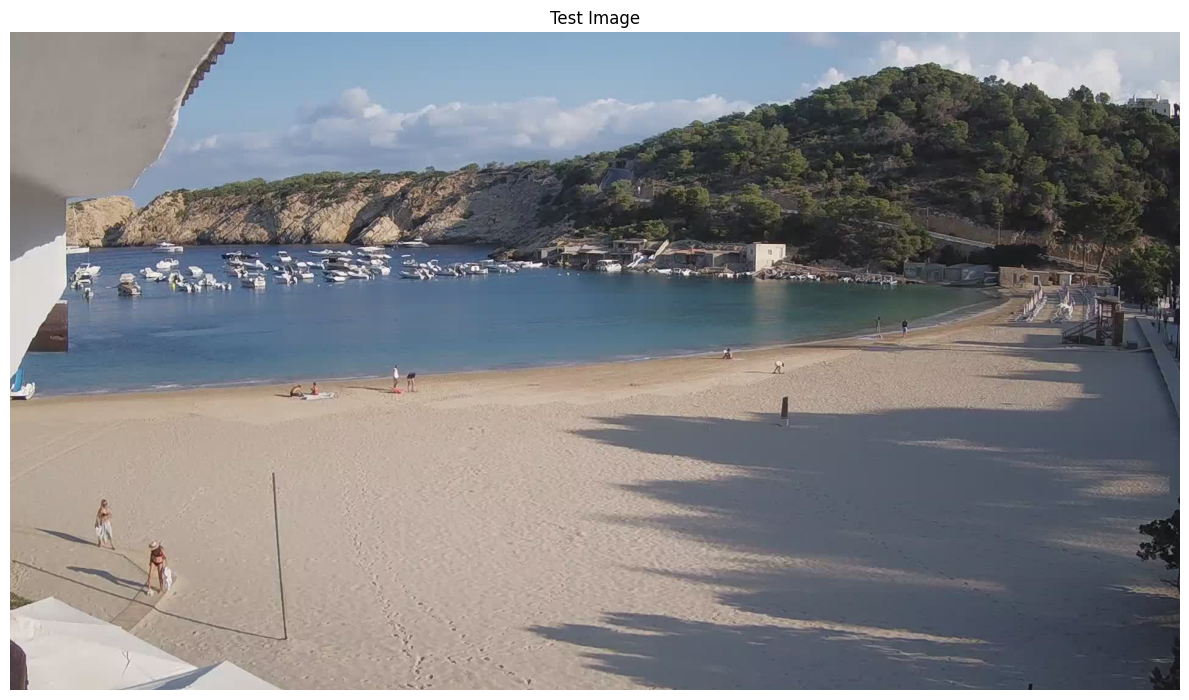

In [6]:
# Cell: Display the test image

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Test Image")
plt.axis('off')
plt.tight_layout()
plt.show()

In [3]:
# Cell: Debug wrapper that reproduces steps and returns intermediates
def pipeline_debug(
    image_bgr,
    background,
    diff_threshold=50,
    clahe_clip=2.0,
    clahe_tile=8,
    morph_kernel_size=7,
    min_blob_area=50,
    edge_low_thresh=50,
    edge_high_thresh=150,
    use_head_kernel=True,
    head_kernel_radius=4,
):
    """
    Return dict with all intermediate images (uint8 where applicable) and final detections.
    """
    out = {}
    H, W = background.shape

    # Step 0: ensure grayscale float images
    img_gray_u8 = ensure_gray(image_bgr).astype(np.uint8)                 # uint8
    out['img_gray'] = img_gray_u8.copy()

    bg_u8 = np.clip(background, 0, 255).astype(np.uint8)
    out['background'] = bg_u8.copy()

    # Step 1: CLAHE
    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=(clahe_tile, clahe_tile))
    img_clahe = clahe.apply(img_gray_u8)            # uint8
    out['img_clahe'] = img_clahe.copy()

    # Step 2: absdiff + threshold -> raw foreground mask
    diff = cv2.absdiff(img_clahe, bg_u8)
    out['diff'] = diff.copy()
    _, mask = cv2.threshold(diff, int(diff_threshold), 255, cv2.THRESH_BINARY)
    out['mask_raw'] = mask.copy()

    # Step 3: morphological cleanup on mask
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
    mask_open = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    mask_close = cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, k)
    out['mask_open'] = mask_open.copy()
    out['mask_clean'] = mask_close.copy()

    # Step 4: edge detection (Canny)
    edges = cv2.Canny(img_clahe, threshold1=edge_low_thresh, threshold2=edge_high_thresh)
    out['edges'] = edges.copy()

    # Step 5: edges within foreground
    edges_fg = cv2.bitwise_and(edges, mask_close)
    out['edges_fg'] = edges_fg.copy()

    # Step 6: morphological refinement on edges_fg, fill contours
    k2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    edges_fg_close = cv2.morphologyEx(edges_fg, cv2.MORPH_CLOSE, k2)
    edges_fg_dil = cv2.dilate(edges_fg_close, k2, iterations=1)
    out['edges_fg_close'] = edges_fg_close.copy()
    out['edges_fg_dil'] = edges_fg_dil.copy()

    contours, _ = cv2.findContours(edges_fg_dil, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(mask_close)
    cv2.drawContours(filled, contours, -1, color=255, thickness=cv2.FILLED)
    out['filled'] = filled.copy()

    # Step 7: combine filled with mask_clean -> candidate mask
    candidates_mask = cv2.bitwise_and(mask_close, filled)
    out['candidates_mask'] = candidates_mask.copy()

    # Step 8: compute centroids
    centroids = centroids_from_binary_mask(candidates_mask, min_area=min_blob_area)
    out['centroids_before_kernel'] = centroids.copy()

    # Step 9: head kernel (optional) — also produce kernel image for visualization
    if use_head_kernel:
        r = head_kernel_radius
        kr = 2*r + 1
        y, x = np.ogrid[-r:r+1, -r:r+1]
        circle = (x*x + y*y) <= (r*r)
        circle_kernel = (circle.astype(np.uint8) * 255)
        out['head_kernel'] = circle_kernel.copy()

        centroids_filtered = []
        for (cx, cy, area) in centroids:
            x0 = cx - r
            y0 = cy - r
            x1 = cx + r
            y1 = cy + r
            if x0 < 0 or y0 < 0 or x1 >= W or y1 >= H:
                continue
            patch = candidates_mask[y0:y1+1, x0:x1+1]
            if patch.shape != circle_kernel.shape:
                continue
            overlap = int(np.sum((patch > 0).astype(np.uint8) * (circle.astype(np.uint8))))
            if overlap >= 0.3 * np.sum(circle):  # 30% overlap threshold (same as module)
                centroids_filtered.append((cx, cy, area))
        out['centroids'] = centroids_filtered
    else:
        out['head_kernel'] = None
        out['centroids'] = centroids

    # For visualization: create overlay image (rgb) showing candidates and centroids on original BGR
    overlay = image_bgr.copy()
    # draw candidate mask contour (green)
    cand_contours, _ = cv2.findContours(candidates_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, cand_contours, -1, (0,255,0), thickness=2)
    # draw centroids and small circles
    for (cx, cy, area) in out['centroids']:
        cv2.circle(overlay, (cx, cy), radius=3, color=(0,0,255), thickness=-1)
        cv2.putText(overlay, f"{area}", (cx+6, cy-6), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0,255), 1, cv2.LINE_AA)
    out['overlay'] = overlay

    # Also produce a visualization of bounding boxes for each centroid from connected components
    # (find CCs and boxes)
    num_labels, labels, stats, cents = cv2.connectedComponentsWithStats((candidates_mask>0).astype(np.uint8)*255, connectivity=8)
    boxes_img = image_bgr.copy()
    for label in range(1, num_labels):
        area = int(stats[label, cv2.CC_STAT_AREA])
        if area < min_blob_area:
            continue
        x = int(stats[label, cv2.CC_STAT_LEFT])
        y = int(stats[label, cv2.CC_STAT_TOP])
        w = int(stats[label, cv2.CC_STAT_WIDTH])
        h = int(stats[label, cv2.CC_STAT_HEIGHT])
        cv2.rectangle(boxes_img, (x,y), (x+w, y+h), (255,0,0), 2)
    out['boxes_img'] = boxes_img

    return out


In [29]:
params = {
    "diff_threshold": 100,
    "clahe_clip": 3.0,
    "clahe_tile": 8,
    "morph_kernel_size": 7,
    "min_blob_area": 50,
    "edge_low_thresh": 50,
    "edge_high_thresh": 150,
    "use_head_kernel": True,
    "head_kernel_radius": 7,
}

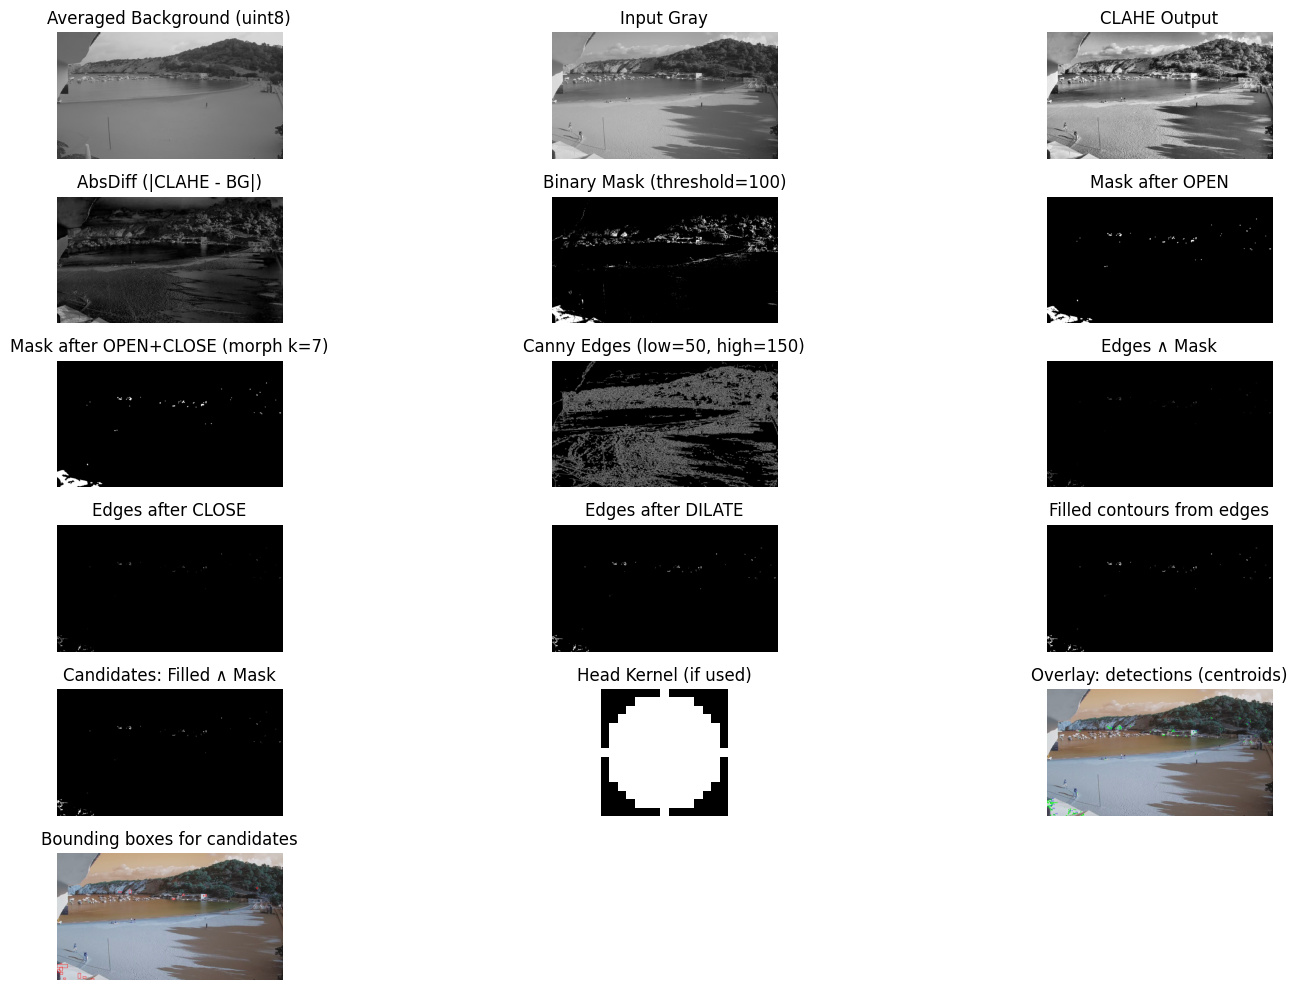

In [30]:
# Cell: Set parameters and run debug pipeline (change params here)
debug = pipeline_debug(
    image_bgr=img_bgr,
    background=bg,
    diff_threshold=params["diff_threshold"],
    clahe_clip=params["clahe_clip"],
    clahe_tile=params["clahe_tile"],
    morph_kernel_size=params["morph_kernel_size"],
    min_blob_area=params["min_blob_area"],
    edge_low_thresh=params["edge_low_thresh"],
    edge_high_thresh=params["edge_high_thresh"],
    use_head_kernel=params["use_head_kernel"],
    head_kernel_radius=params["head_kernel_radius"],
)

# Display a grid of intermediate images
imgs = [
    (debug['background'], "Averaged Background (uint8)"),
    (debug['img_gray'], "Input Gray"),
    (debug['img_clahe'], "CLAHE Output"),
    (debug['diff'], f"AbsDiff (|CLAHE - BG|)"),
    (debug['mask_raw'], f"Binary Mask (threshold={params['diff_threshold']})"),
    (debug['mask_open'], "Mask after OPEN"),
    (debug['mask_clean'], f"Mask after OPEN+CLOSE (morph k={params['morph_kernel_size']})"),
    (debug['edges'], f"Canny Edges (low={params['edge_low_thresh']}, high={params['edge_high_thresh']})"),
    (debug['edges_fg'], "Edges ∧ Mask"),
    (debug['edges_fg_close'], "Edges after CLOSE"),
    (debug['edges_fg_dil'], "Edges after DILATE"),
    (debug['filled'], "Filled contours from edges"),
    (debug['candidates_mask'], "Candidates: Filled ∧ Mask"),
    (debug['head_kernel'] if debug['head_kernel'] is not None else np.zeros((2,2),dtype=np.uint8), "Head Kernel (if used)"),
    (cv2.cvtColor(debug['overlay'], cv2.COLOR_BGR2RGB), "Overlay: detections (centroids)"),
    (cv2.cvtColor(debug['boxes_img'], cv2.COLOR_BGR2RGB), "Bounding boxes for candidates"),
]
show_images_grid(imgs, cols=3, figsize=(15,10))


Centroids (x, y, area): [(1699, 297, 53), (621, 332, 191), (538, 332, 171), (1075, 357, 59), (1266, 359, 92), (1246, 363, 53), (35, 941, 52), (29, 962, 665), (35, 990, 312), (14, 1001, 149), (37, 1024, 184), (190, 1044, 414), (232, 1058, 152), (61, 1069, 102)]
Count: 14


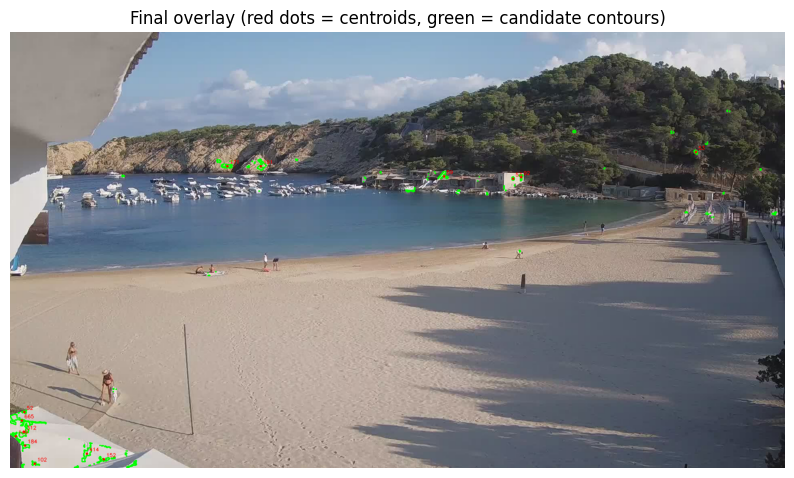

In [31]:
# Cell: Print numeric detection results and quick overlay display (zoomable in notebook)
print("Centroids (x, y, area):", debug['centroids'])
print("Count:", len(debug['centroids']))

# Show overlay again but larger
plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(debug['overlay'], cv2.COLOR_BGR2RGB))
plt.title("Final overlay (red dots = centroids, green = candidate contours)")
plt.axis('off')
plt.show()
